In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import seaborn as sns


혼동 행렬 예시:
[[3 1]
 [1 3]]


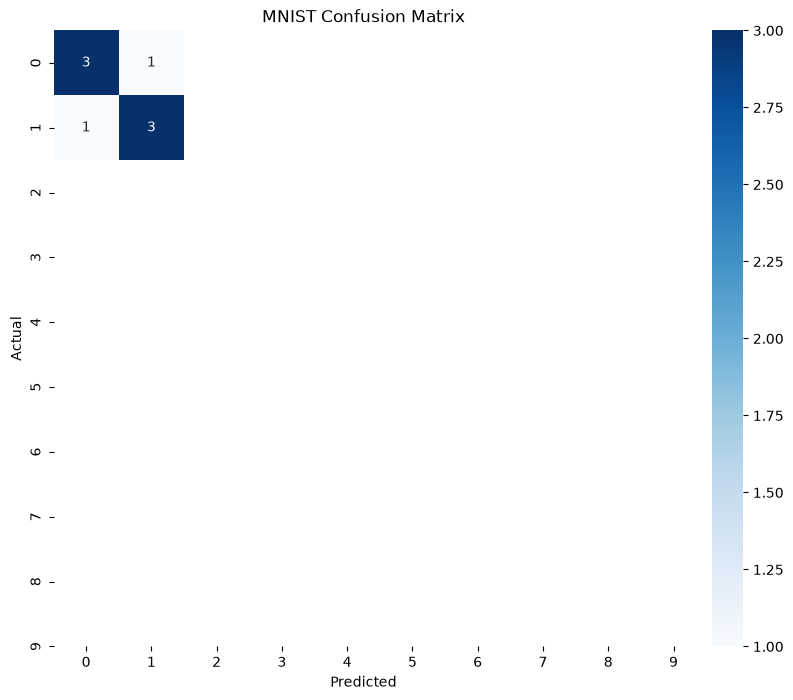

In [24]:
# 혼동 행렬 분석
y_true = np.array([0,1,0,1,1,0,1,0])
y_pred = np.array([0,1,1,1,1,0,0,0])

cm = confusion_matrix(y_true, y_pred)
print(f"\n혼동 행렬 예시:\n{cm}")

# 실제 MNIST 결과로 혼동 행렬 생성
cm_mnist = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_mnist, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('MNIST Confusion Matrix')
plt.show()

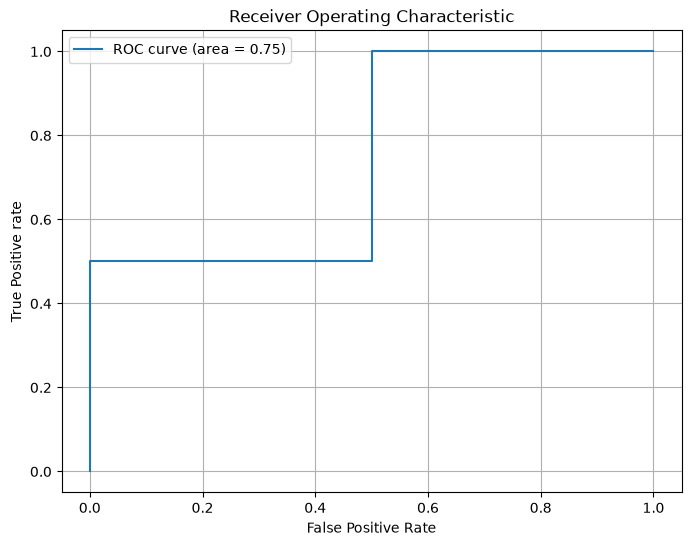

In [25]:
y_scores = np.array([0.1, 0.4, 0.35, 0.8])
y_test = np.array([0, 0, 1, 1])

fpr, tpr, _ = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

In [26]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307), (0.3081,))
])


train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, transform=transform, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=1000, shuffle=False)


class MLP_Final(nn.Module):
    def __init__(self):
        super(MLP_Final, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = x.view(-1, 28*28)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f'\n학습 장치 : {device}\n')

model = MLP_Final().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("최종 모델 학습 중...")


학습 장치 : xpu

최종 모델 학습 중...


In [29]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)
for epoch in range(50):
    train_loss = 0.2 * (50 - epoch)
    scheduler.step(train_loss)

In [31]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)
for epoch in range(50):
    train_loss = 0.2 * (50 - epoch)

    old_lr = optimizer.param_groups[0]["lr"]

    scheduler.step(train_loss)

    new_lr = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch [{epoch + 1:02d}/50] "
        f"train_loss: {train_loss:.4f} "
        f"lr: {old_lr:.6f} -> {new_lr:.6f}"
    )

Epoch [01/50] train_loss: 10.0000 lr: 0.001000 -> 0.001000
Epoch [02/50] train_loss: 9.8000 lr: 0.001000 -> 0.001000
Epoch [03/50] train_loss: 9.6000 lr: 0.001000 -> 0.001000
Epoch [04/50] train_loss: 9.4000 lr: 0.001000 -> 0.001000
Epoch [05/50] train_loss: 9.2000 lr: 0.001000 -> 0.001000
Epoch [06/50] train_loss: 9.0000 lr: 0.001000 -> 0.001000
Epoch [07/50] train_loss: 8.8000 lr: 0.001000 -> 0.001000
Epoch [08/50] train_loss: 8.6000 lr: 0.001000 -> 0.001000
Epoch [09/50] train_loss: 8.4000 lr: 0.001000 -> 0.001000
Epoch [10/50] train_loss: 8.2000 lr: 0.001000 -> 0.001000
Epoch [11/50] train_loss: 8.0000 lr: 0.001000 -> 0.001000
Epoch [12/50] train_loss: 7.8000 lr: 0.001000 -> 0.001000
Epoch [13/50] train_loss: 7.6000 lr: 0.001000 -> 0.001000
Epoch [14/50] train_loss: 7.4000 lr: 0.001000 -> 0.001000
Epoch [15/50] train_loss: 7.2000 lr: 0.001000 -> 0.001000
Epoch [16/50] train_loss: 7.0000 lr: 0.001000 -> 0.001000
Epoch [17/50] train_loss: 6.8000 lr: 0.001000 -> 0.001000
Epoch [18/50]

In [34]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.1)

for epoch in range(50):
    train_loss = 0.2 * (50 - epoch)

    old_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(train_loss)
    new_lr = optimizer.param_groups[0]["lr"]

    if old_lr != new_lr:
        print(
            f"Epoch [{epoch + 1:02d}/50] "
            f"train_loss: {train_loss:.4f} "
            f"lr changed: {old_lr:.6f} -> {new_lr:.6f}"
        )
    else:
        print(
            f"Epoch [{epoch + 1:02d}/50] "
            f"train_loss: {train_loss:.4f} "
            f"lr: {new_lr:.6f}"
        )

Epoch [01/50] train_loss: 10.0000 lr: 0.001000
Epoch [02/50] train_loss: 9.8000 lr: 0.001000
Epoch [03/50] train_loss: 9.6000 lr: 0.001000
Epoch [04/50] train_loss: 9.4000 lr: 0.001000
Epoch [05/50] train_loss: 9.2000 lr: 0.001000
Epoch [06/50] train_loss: 9.0000 lr: 0.001000
Epoch [07/50] train_loss: 8.8000 lr: 0.001000
Epoch [08/50] train_loss: 8.6000 lr: 0.001000
Epoch [09/50] train_loss: 8.4000 lr: 0.001000
Epoch [10/50] train_loss: 8.2000 lr: 0.001000
Epoch [11/50] train_loss: 8.0000 lr: 0.001000
Epoch [12/50] train_loss: 7.8000 lr: 0.001000
Epoch [13/50] train_loss: 7.6000 lr: 0.001000
Epoch [14/50] train_loss: 7.4000 lr: 0.001000
Epoch [15/50] train_loss: 7.2000 lr: 0.001000
Epoch [16/50] train_loss: 7.0000 lr: 0.001000
Epoch [17/50] train_loss: 6.8000 lr: 0.001000
Epoch [18/50] train_loss: 6.6000 lr: 0.001000
Epoch [19/50] train_loss: 6.4000 lr: 0.001000
Epoch [20/50] train_loss: 6.2000 lr: 0.001000
Epoch [21/50] train_loss: 6.0000 lr: 0.001000
Epoch [22/50] train_loss: 5.8000 

In [35]:
  import torch
  import torch.nn as nn

  bn = nn.BatchNorm1d(3)

  x = torch.tensor([
      [1.0, 2.0, 3.0],
      [2.0, 3.0, 4.0],
      [3.0, 4.0, 5.0],
  ])

  bn.train()
  out = bn(x)

  print("running_mean:", bn.running_mean)
  print("running_var:", bn.running_var)

running_mean: tensor([0.2000, 0.3000, 0.4000])
running_var: tensor([1., 1., 1.])
